<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/%EC%9C%A4%EC%84%B8%EC%B0%AC_6_1_%EA%B5%B0%EC%A7%91_%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98_ipynb(%ED%95%99%EC%83%9D%EC%9A%A9)%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 군집 알고리즘

<img src="https://lh3.googleusercontent.com/notebooklm/AKXwDQFIHY3nWdkaoUzB2mw_qpH76KLHmegPe2I6QDdh0iKz3kVmvpyBbxpm71bv8Xpk4QKTET4jx0fhrB9zuA9w1p69apAG7GJ99pALsQ1WYmWlMFx6Z7Q5X4KIAcUlUPZ05ZCiqq2lpWOnG0273x-lU5k6vJe__lGoAlkwzA=w1376-h768?authuser=0">

## 과일 사진 데이터 준비하기

In [ ]:
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-05-17 23:30:25--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-05-17 23:30:25--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-05-17 23:30:26--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... conne

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
fruits = np.load('fruits_300.npy')

In [ ]:
print(fruits.shape)

(300, 100, 100)


In [ ]:
for row in fruits[0]:
    for pixel in row:
        # 3d: 3칸 확보 후 정수(d) 출력.
        # end=" ": 줄바꿈 대신 띄어쓰기로 이어 붙임
        print(f"{pixel:3d}", end=" ")
    print() # 한 줄

  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   2   1   2   2   2   2   2   2   1   1   1   1   1   1   1   1   2   3   2   1   2   1   1   1   1   2   1   3   2   1   3   1   4   1   2   5   5   5  19 148 192 117  28   1   1   2   1   4   1   1   3   1   1   1   1   1   2   2   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   2   2   1   1   1   1   2   4   3   1   2   1   1   1   1   1   2   2   3   1   2   2   3  24 112 163 229 132  30   1   4   2   2   2   3   2   1   1   3   1   2   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   2   1   1   1   1   1   1   1   1   2   2   2   1   2   2   1   1   1   1   2   3   1   1   1   4   2   3   4   

#이미지 출력
<font size=5>이미지에서 1과 255가 갖는 의미는??<br>어두운색 = 낮음(0에 가깝다.) <br>밝은색 = 높음(255에 가깝다)
<img src="https://drive.google.com/thumbnail?id=1K_-Epe7coIlWtXG73tEWEogpFrDhZsNg&sz=w1000">


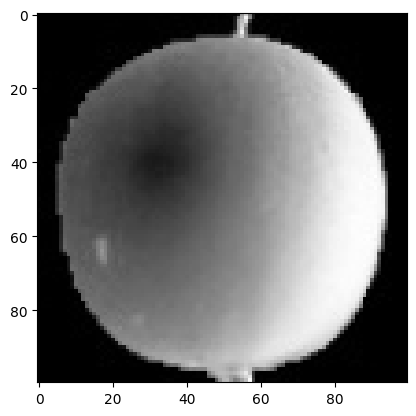

In [ ]:
plt.imshow(fruits[0], cmap='gray')
plt.show()

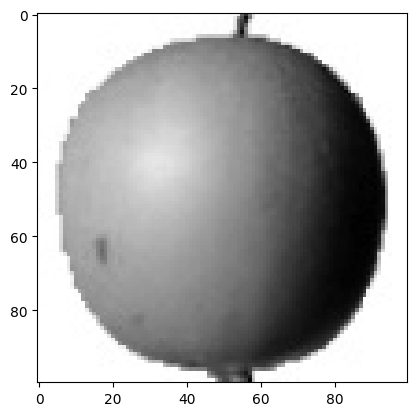

In [ ]:
plt.imshow(fruits[0], cmap='gray_r')
plt.show()

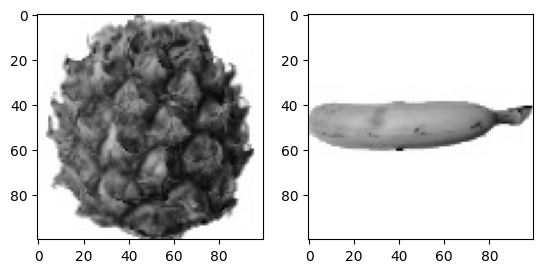

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(fruits[100], cmap='gray_r')
axs[1].imshow(fruits[200], cmap='gray_r')
plt.show()

## 픽셀 값 분석하기

<img src="https://drive.google.com/thumbnail?id=1HlJ4nMmO5WE4THwPHNiy7kVo700IUpyv&sz=w1000">

In [ ]:
apple = fruits[0:100].reshape(-1,100*100)
pineapple = fruits[100:200].reshape(-1,100*100)
banana = fruits[200:300].reshape(-1,100*100)

In [ ]:
print(apple.shape)

(100, 10000)


In [ ]:
print(apple.mean(axis=1))

[ 88.3346  97.9249  87.3709  98.3703  92.8705  82.6439  94.4244  95.5999
  90.681   81.6226  87.0578  95.0745  93.8416  87.017   97.5078  87.2019
  88.9827 100.9158  92.7823 100.9184 104.9854  88.674   99.5643  97.2495
  94.1179  92.1935  95.1671  93.3322 102.8967  94.6695  90.5285  89.0744
  97.7641  97.2938 100.7564  90.5236 100.2542  85.8452  96.4615  97.1492
  90.711  102.3193  87.1629  89.8751  86.7327  86.3991  95.2865  89.1709
  96.8163  91.6604  96.1065  99.6829  94.9718  87.4812  89.2596  89.5268
  93.799   97.3983  87.151   97.825  103.22    94.4239  83.6657  83.5159
 102.8453  87.0379  91.2742 100.4848  93.8388  90.8568  97.4616  97.5022
  82.446   87.1789  96.9206  90.3135  90.565   97.6538  98.0919  93.6252
  87.3867  84.7073  89.1135  86.7646  88.7301  86.643   96.7323  97.2604
  81.9424  87.1687  97.2066  83.4712  95.9781  91.8096  98.4086 100.7823
 101.556  100.7027  91.6098  88.8976]


#plt.hist() 핵심 키워드

<font size= 5>
히스토그램은 수많은 데이터를 '구간(Bins, 바구니)'으로 나누어, 각 바구니에 데이터가 몇 개씩 들어있는지 높이로 보여주는 그래프입니다.

1. <font size= 5>x (필수) : 내 데이터

    * <font size= 5>설명: 바구니에 담을 흩어진 데이터들의 모음입니다. (예: 전교생의 수학 점수 리스트)

2. <font size= 5>bins (핵심) : 바구니의 개수

    * <font size= 5>설명: 데이터를 몇 개의 구간으로 쪼갤지 결정합니다.

    * <font size= 5>팁: bins=10이라고 쓰면 10등분을 하고, bins=[0, 50, 80, 100]처럼 리스트를 주면 내 마음대로 바구니의 크기(구간)를 정할 수 있습니다. 히스토그램의 모양을 결정하는 가장 중요한 옵션입니다.

3. <font size= 5>density : 개수 말고 '비율(확률)'로 보기

    * <font size= 5>설명: 기본값(False)은 바구니에 담긴 데이터의 '개수'를 보여줍니다. 하지만 True로 바꾸면 전체 데이터 중 차지하는 '비율(면적의 합이 1이 됨)'로 높이를 바꿔줍니다. (상대도수 분포표와 같습니다.)

4. <font size= 5>histtype : 그래프의 스타일

    * <font size= 5>설명: 막대의 모양을 바꿉니다.

    * <font size= 5>종류: 'bar'(기본 꽉 찬 막대), 'step'(색칠 없이 계단처럼 테두리 선만 그림). 두 개의 데이터를 겹쳐 그릴 때 'step'이 아주 유용합니다.

5. <font size= 5>color & alpha (보너스 kwargs) : 색상과 투명도

    * <font size= 5>설명: color는 막대의 색상을, alpha는 투명도(0.0 ~ 1.0)를 지정합니다. 데이터 두 개를 겹쳐 그릴 때 alpha=0.5 반투명하게 주면 뒤에 있는 막대도 예쁘게 잘 보입니다.

##히스토 그램 해석
각각의 평균이 의미하는 것은??

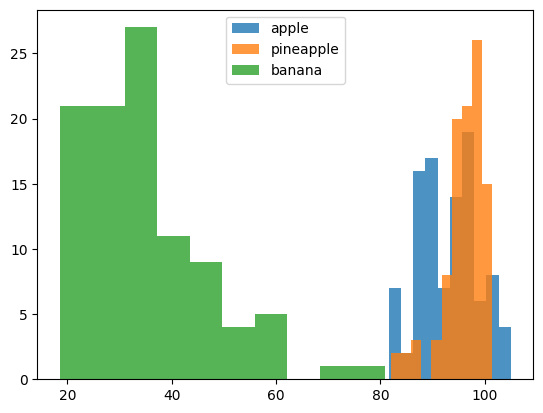

In [ ]:
plt.hist(apple.mean(axis=1), alpha = 0.8)
plt.hist(pineapple.mean(axis=1), alpha = 0.8)
plt.hist(banana.mean(axis=1), alpha = 0.8)
plt.legend(['apple','pineapple','banana'])

##plt.subplot()
<font size =5>`plt.subplot(nrows, ncols, index) `형태로 사용하며, 세 개의 숫자가 나란히 붙어있기 때문에 콤마를 생략하고 plt.subplot(221)처럼 줄여 쓰기도 합니다.

* <font size =5>nrows (행): 가로줄을 몇 개로 나눌 것인가?

* <font size =5>ncols (열): 세로줄을 몇 개로 나눌 것인가?

* <font size =5>index (위치): 쪼개진 칸들 중 어디에 그릴 것인가? (🚨 주의: 파이썬의 일반적인 인덱스와 달리 0이 아니라 1부터 시작합니다!) 좌측 상단부터 우측으로 1, 2, 3... 순서로 번호가 매겨집니다.
* <font size = 5> figsize=(가로, 세로) : 단위는 인치(inch)를 기준으로 합니다.

<BarContainer object of 10000 artists>

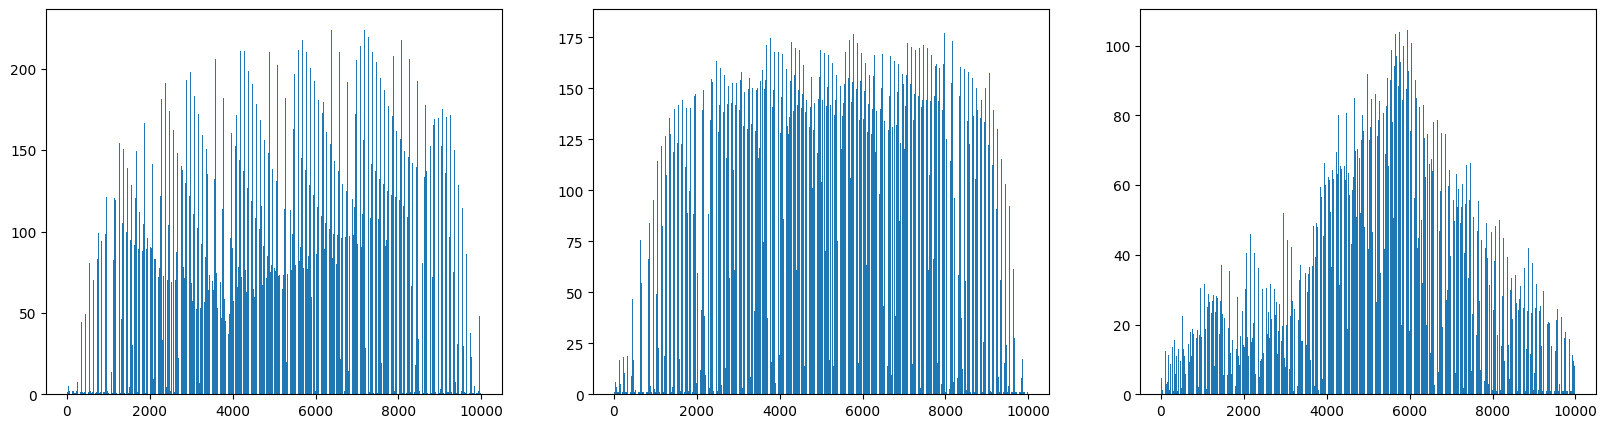

In [ ]:
fig, axs = plt.subplots(1, 3, figsize = (20,5))
axs[0].bar(range(10000),np.mean(apple, axis=0))
axs[1].bar(range(10000),np.mean(pineapple, axis=0))
axs[2].bar(range(10000),np.mean(banana, axis=0))

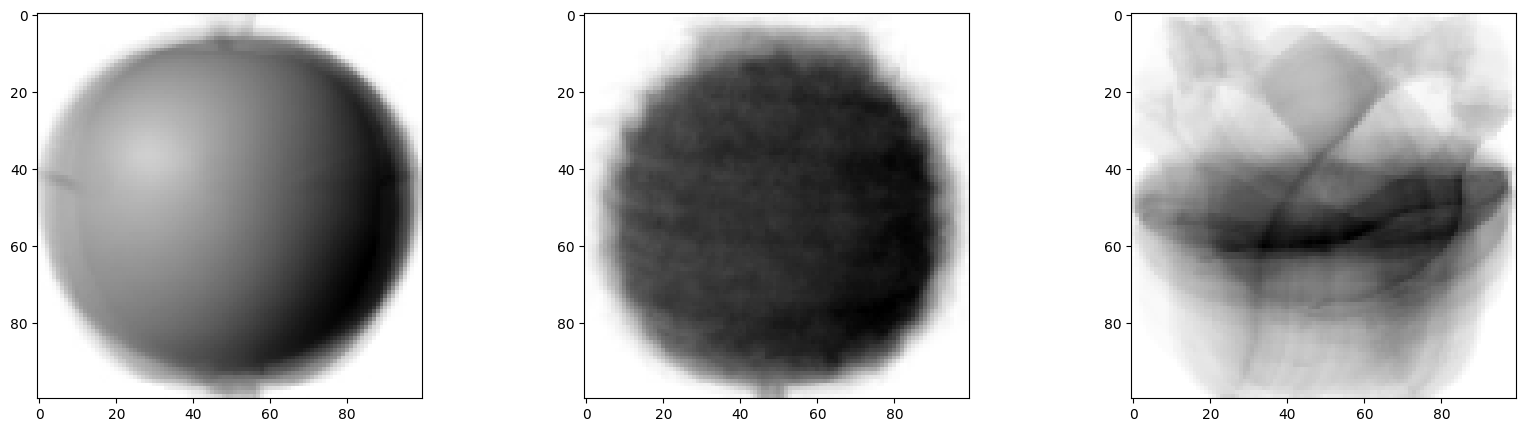

In [ ]:
apple_mean = np.mean(apple, axis=0).reshape(100,100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100,100)
banana_mean = np.mean(banana, axis=0).reshape(100,100)

fig ,axs = plt.subplots(1, 3, figsize=(20,5))

axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')
plt.show()

## 평균값과 가까운 사진 고르기

##절대값 오차

In [ ]:
abs_diff = np.abs(fruits - apple_mean)
abs_mean = np.mean(abs_diff, axis=(1,2))
abs_mean.shape

(300,)

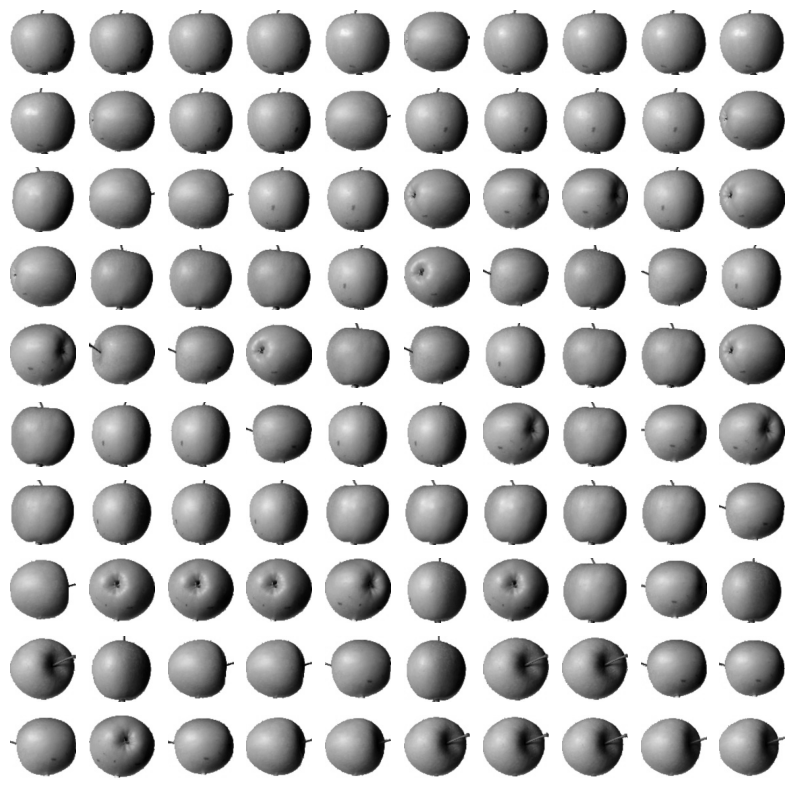

In [ ]:
apple_index = np.argsort(abs_mean)[:100]
apple_index = apple_index.reshape(10,10)
fig ,axs = plt.subplots(10,10, figsize=(10,10))
for i in range(10):
  for j in range(10):
    axs[i,j].imshow(fruits[apple_index[i,j]],cmap='gray_r')
    axs[i,j].axis('off')
plt.show()

## 확인문제

In [ ]:
abs_diff = np.abs(fruits - pineapple_mean)
abs_mean = np.mean(abs_diff, axis=(1,2))
abs_mean.shape

(300,)

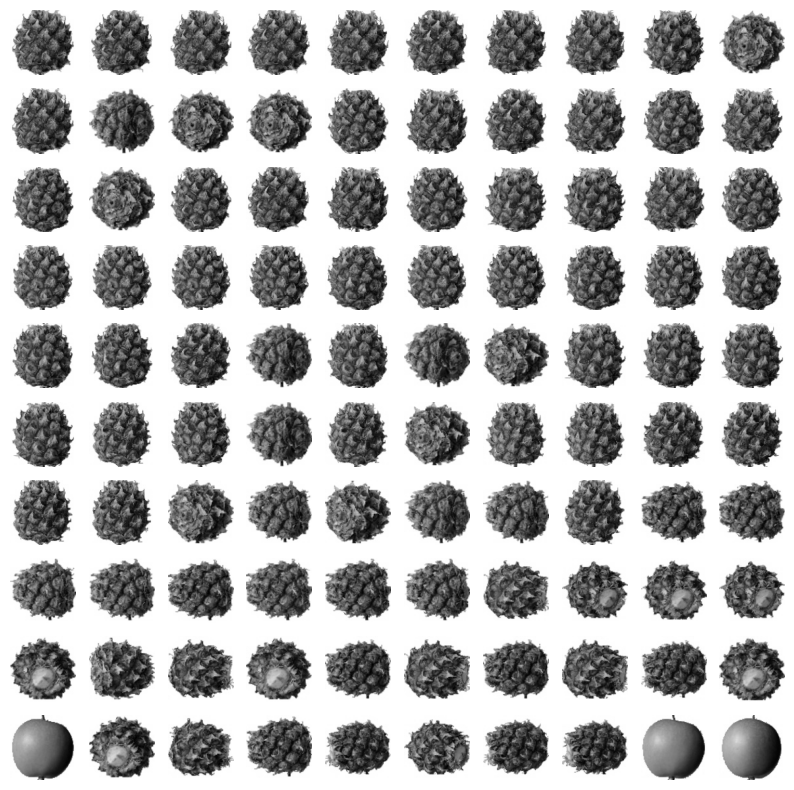

In [ ]:
pineapple_index = np.argsort(abs_mean)[:100]
pineapple_index = pineapple_index.reshape(10,10)
fig ,axs = plt.subplots(10,10, figsize=(10,10))
for i in range(10):
  for j in range(10):
    axs[i,j].imshow(fruits[pineapple_index[i,j]],cmap='gray_r')
    axs[i,j].axis('off')
plt.show()

In [ ]:
abs_diff = np.abs(fruits - banana_mean)
abs_mean = np.mean(abs_diff, axis=(1,2))
abs_mean.shape

(300,)

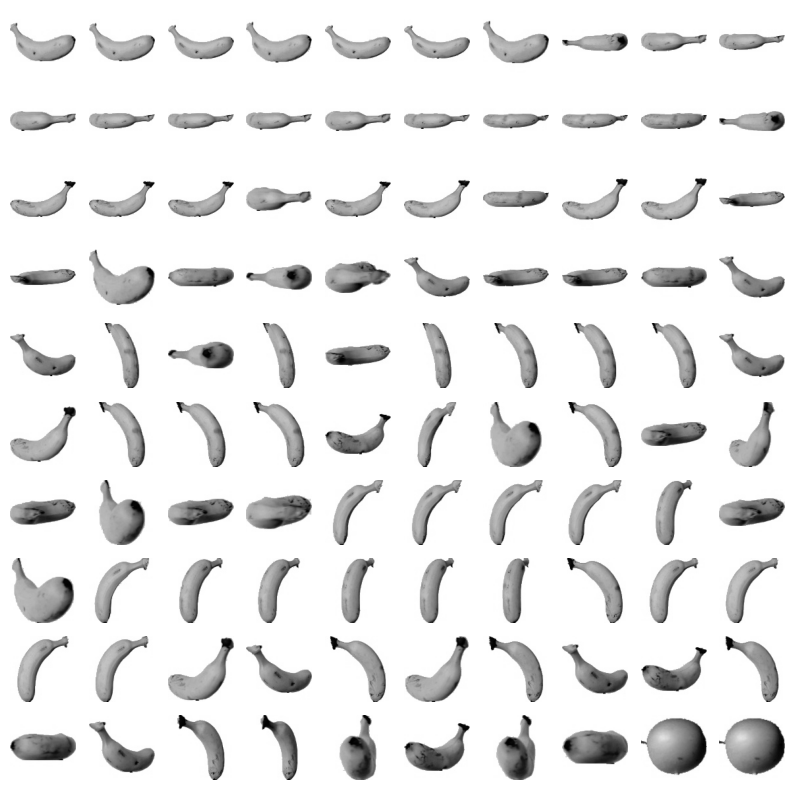

In [ ]:
banana_index = np.argsort(abs_mean)[:100]
banana_index = banana_index.reshape(10,10)
fig ,axs = plt.subplots(10,10, figsize=(10,10))
for i in range(10):
  for j in range(10):
    axs[i,j].imshow(fruits[banana_index[i,j]],cmap='gray_r')
    axs[i,j].axis('off')
plt.show()